In [ ]:
# ============================================================
# BLOQUE 1
# ============================================================

# Instalamos rapidfuzz, que necesitaremos para la deduplicación difusa
!pip install rapidfuzz -q

# Librerías estándar de análisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from collections import Counter
import ast
import re
from rapidfuzz import fuzz
import warnings
warnings.filterwarnings('ignore')

# Configuración visual de los gráficos
plt.style.use('seaborn-v0_8-muted')
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Librerías cargadas correctamente")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 24.0 MB/s eta 0:00:00
✅ Librerías cargadas correctamente


In [ ]:
# ============================================================
# CARGA DEL DATASET
# ============================================================
from google.colab import drive
drive.mount("/content/drive")

CSV_PATH = "/content/drive/MyDrive/books_database_third.csv"

df = pd.read_csv(CSV_PATH, dtype={"isbn_13": str, "isbn_10": str}  # Evitar notación científica
)

print("=" * 60)
print("FASE 1 — EDA DEL DATASET DE LIBROS")
print("=" * 60)
print(f"\n✅ Dataset cargado correctamente")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n   Nombres de columnas:")
for col in df.columns:
    print(f"     - {col}")

print("\n--- PRIMERAS 3 FILAS ---")
print(df.head(3).to_string())

print("\n--- TIPOS DE DATOS POR COLUMNA ---")
print(df.dtypes)

Mounted at /content/drive
FASE 1 — EDA DEL DATASET DE LIBROS

✅ Dataset cargado correctamente
   Filas    : 10,951
   Columnas : 12

   Nombres de columnas:
     - title
     - authors
     - publisher
     - description
     - categories
     - assigned_category
     - page_count
     - year
     - isbn_13
     - isbn_10
     - thumbnail
     - info_link

--- PRIMERAS 3 FILAS ---
                                                     title           authors                  publisher                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

--- VALORES NULOS POR COLUMNA ---

                   Nulos  Porcentaje (%)
isbn_10             2622           23.94
isbn_13             2211           20.19
publisher           1443           13.18
categories           708            6.47
thumbnail            375            3.42
year                 141            1.29
page_count            68            0.62
title                  0            0.00
description            0            0.00
authors                0            0.00
assigned_category      0            0.00
info_link              0            0.00


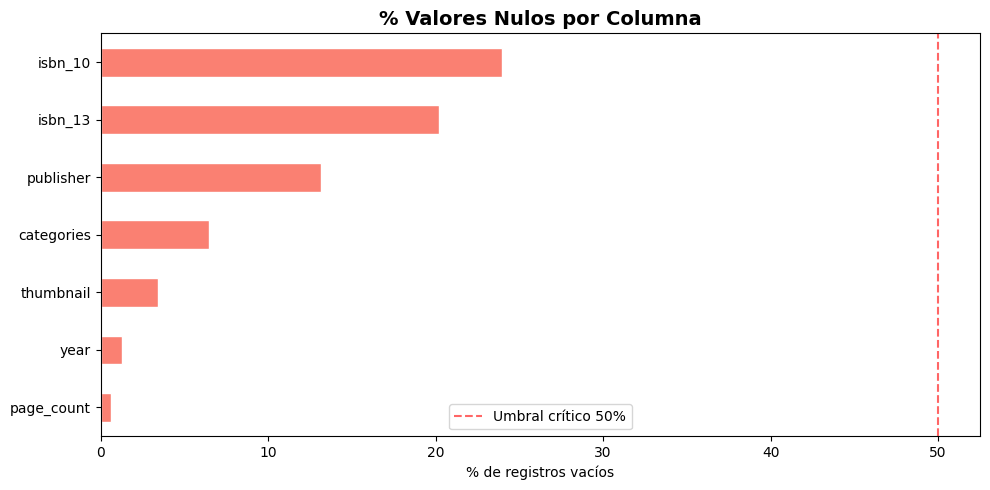


✅ Bloque 3 completado


In [ ]:
# ============================================================
# VALORES NULOS
# ============================================================

nulls    = df.isnull().sum()                       # Cuenta nulos por columna
null_pct = (nulls / len(df) * 100).round(2)        # Convierte a porcentaje

null_df = pd.DataFrame({
    'Nulos': nulls,
    'Porcentaje (%)': null_pct
}).sort_values('Porcentaje (%)', ascending=False)

print("--- VALORES NULOS POR COLUMNA ---\n")
print(null_df.to_string())

# ============================================================
# GRÁFICO: columnas con mayor porcentaje de nulos
# ============================================================
columnas_con_nulos = null_pct[null_pct > 0].sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
columnas_con_nulos.plot(kind='barh', ax=ax, color='salmon', edgecolor='white')
ax.set_title("% Valores Nulos por Columna", fontsize=14, fontweight='bold')
ax.set_xlabel("% de registros vacíos")
# Línea roja en 50%: si una columna supera esto, es problemática
ax.axvline(x=50, color='red', linestyle='--', alpha=0.6, label='Umbral crítico 50%')
ax.legend()
plt.tight_layout()
plt.show()

print("\n✅ Bloque 3 completado")

--- ANÁLISIS DE 'description' ---

   Total libros          : 10,951
   Con descripción       : 10,951
   Vacías (0 chars)      : 0

   Longitud promedio     : 991 caracteres
   Longitud mediana      : 892 caracteres
   Descripción más corta : 1 caracteres
   Descripción más larga : 14,015 caracteres

   Descripciones < 50 chars  (descartar) : 138
   Descripciones < 100 chars (muy cortas): 451
   Descripciones >= 100 chars (útiles)   : 10,500

   Ejemplos de descripciones más cortas:
                                           title                                      description
                              Library Literature   "An index to library and information science".
                                 Magical Realism                 On magical realism in literature
Synopsis of 100's Fantasy Story Titles - English Synopsis of 100's Fantasy Story Titles - English
                          Fantasy and the Cinema                               No Marketing Blurb
                     

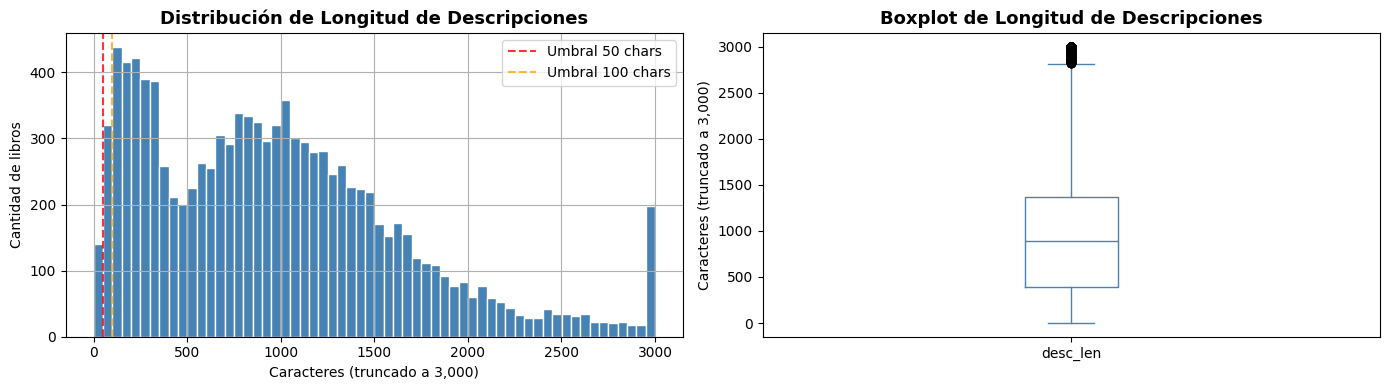


✅ Bloque 4 completado


In [ ]:
# ============================================================
# ANÁLISIS DE 'description'
# Esta es la columna MÁS IMPORTANTE del pipeline.
# TF-IDF la vectoriza, BERT la analiza semánticamente.
# Necesitamos saber qué tan largas son las descripciones:
# muy cortas = poco contexto para los modelos.
# ============================================================

# Calculamos la longitud en caracteres de cada descripción
# Usamos fillna('') por si acaso hay algún nulo no detectado
df['desc_len'] = df['description'].fillna('').apply(len)

print("--- ANÁLISIS DE 'description' ---\n")
print(f"   Total libros          : {len(df):,}")
print(f"   Con descripción       : {(df['desc_len'] > 0).sum():,}")
print(f"   Vacías (0 chars)      : {(df['desc_len'] == 0).sum():,}")
print(f"\n   Longitud promedio     : {df['desc_len'].mean():.0f} caracteres")
print(f"   Longitud mediana      : {df['desc_len'].median():.0f} caracteres")
print(f"   Descripción más corta : {df['desc_len'].min()} caracteres")
print(f"   Descripción más larga : {df['desc_len'].max():,} caracteres")

# Umbrales de calidad
# < 50 chars = casi vacía, no útil para NLP (ej: "A novel." o "Fiction book.")
# < 100 chars = muy corta, poco contexto
print(f"\n   Descripciones < 50 chars  (descartar) : {(df['desc_len'] < 50).sum():,}")
print(f"   Descripciones < 100 chars (muy cortas): {(df['desc_len'] < 100).sum():,}")
print(f"   Descripciones >= 100 chars (útiles)   : {(df['desc_len'] >= 100).sum():,}")

# Ejemplos de descripciones muy cortas para ver qué contienen
print("\n   Ejemplos de descripciones más cortas:")
print(df[df['desc_len'] < 50][['title', 'description']].head(5).to_string(index=False))

# ============================================================
# GRÁFICO: distribución de longitudes
# clip(upper=3000) recorta el eje X en 3000 chars para que
# el gráfico sea legible (hay outliers con descripciones muy largas)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Izquierdo: todas las descripciones con longitud > 0
df[df['desc_len'] > 0]['desc_len'].clip(upper=3000).hist(
    bins=60, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title("Distribución de Longitud de Descripciones", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Caracteres (truncado a 3,000)")
axes[0].set_ylabel("Cantidad de libros")
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.8, label='Umbral 50 chars')
axes[0].axvline(x=100, color='orange', linestyle='--', alpha=0.8, label='Umbral 100 chars')
axes[0].legend()

# Derecho: boxplot para ver la dispersión
df[df['desc_len'] > 0]['desc_len'].clip(upper=3000).plot(
    kind='box', ax=axes[1], color='steelblue'
)
axes[1].set_title("Boxplot de Longitud de Descripciones", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Caracteres (truncado a 3,000)")

plt.tight_layout()
plt.show()

print("\n✅ Bloque 4 completado")

--- ANÁLISIS DE 'assigned_category' ---

   Categorías únicas : 23

   Distribución completa:
assigned_category
mystery_thriller                    910
fiction                             885
science_fiction                     856
historical_fiction                  840
self_help                           769
fantasy                             747
horror                              727
biography_memoir                    683
non_fiction                         579
young_adult                         541
graphic_novel_comics                410
romance                             366
classics_postmodern_american        365
classics_black_mountain_new_york    311
classics_realism                    299
classics_gothic_romantic            282
classics_latin_american             257
classics_modernism                  247
classics                            240
classics_existentialism             230
classics_postmodernism              206
award_winners                       116
classics

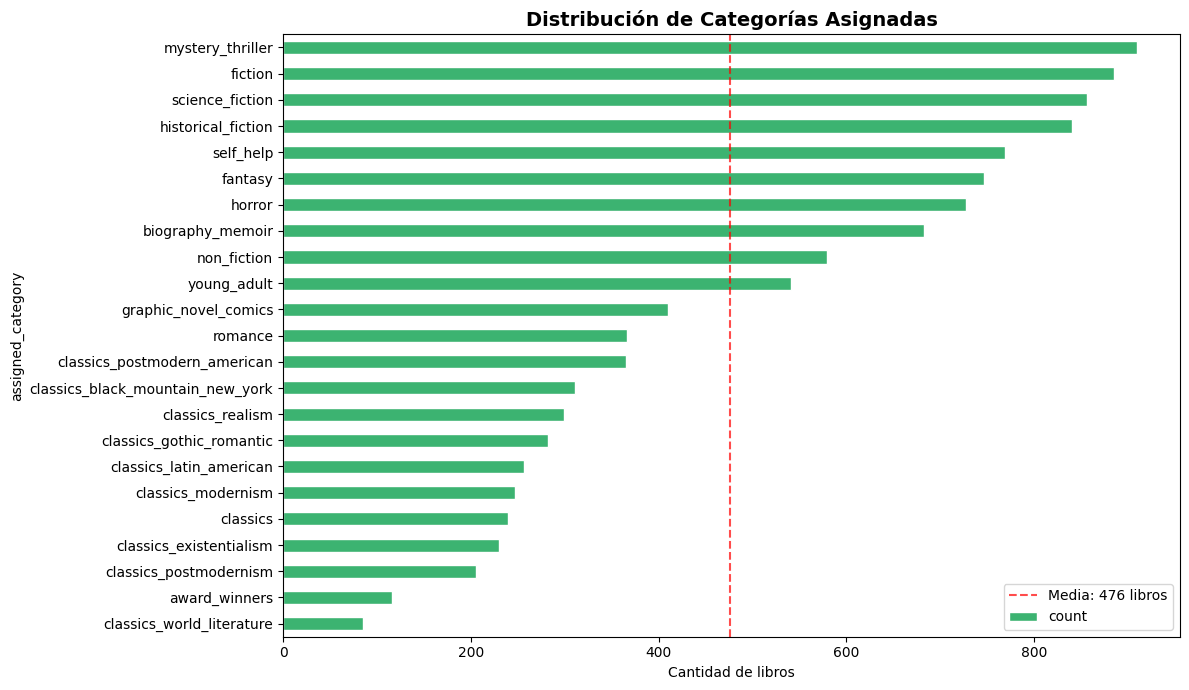


--- ANÁLISIS DE 'categories' (campo original) ---

   Muestra de valores crudos:
['Literary Collections', 'Literary Criticism', 'Juvenile Fiction', 'Education', 'Language Arts & Disciplines', 'Education', 'Literary Criticism', 'Literary Criticism']

   Total etiquetas únicas en 'categories' : 396

   Top 20 etiquetas:
     Fiction                                   3176 libros
     Literary Criticism                        1545 libros
     Biography & Autobiography                  514 libros
     Language Arts & Disciplines                435 libros
     History                                    402 libros
     Social Science                             273 libros
     Performing Arts                            222 libros
     Education                                  210 libros
     Business & Economics                       209 libros
     Literary Collections                       207 libros
     Psychology                                 184 libros
     Self-Help                

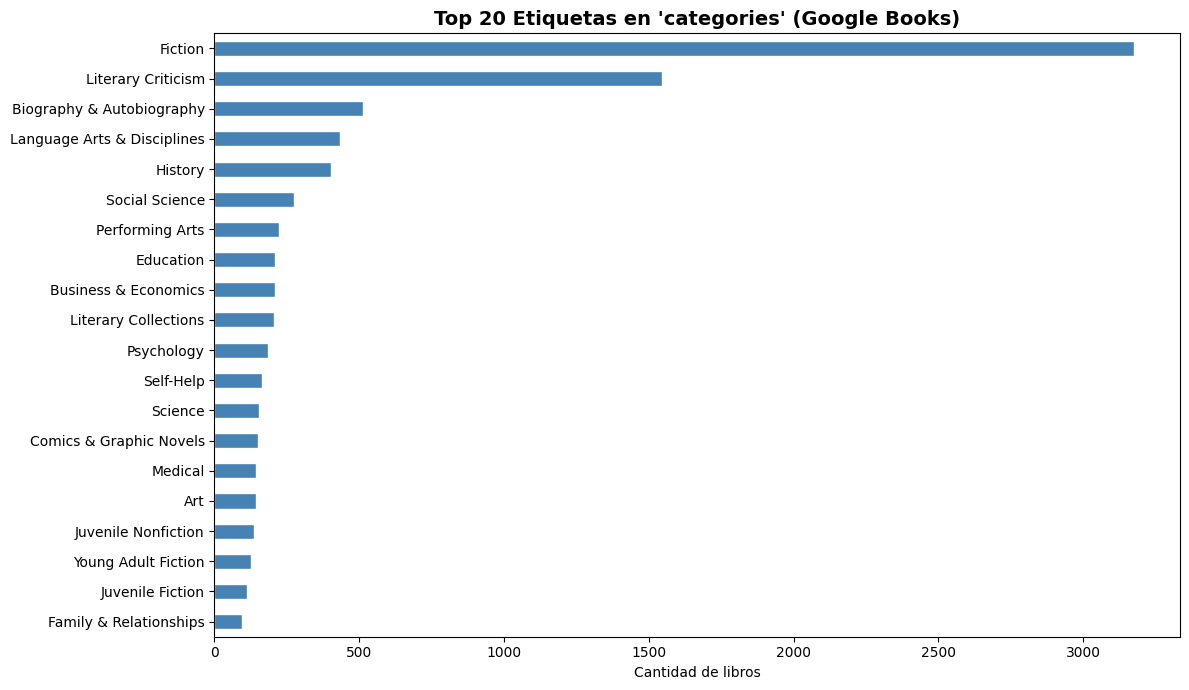


✅ Bloque 5 completado


In [ ]:
# ============================================================
# ANÁLISIS DE CATEGORÍAS
# 'assigned_category' es la categoría limpia (una por libro)
# 'categories' es el campo original de Google Books (puede
# contener listas como "['Fiction', 'Drama', 'Literary']")
#
# Estas etiquetas son clave para el Clustering de Fase 4:
# nos ayudan a entender en qué géneros se mueve el lector.
# ============================================================

print("--- ANÁLISIS DE 'assigned_category' ---\n")

cat_counts = df['assigned_category'].value_counts()
print(f"   Categorías únicas : {df['assigned_category'].nunique()}")
print(f"\n   Distribución completa:")
print(cat_counts.to_string())

# Gráfico de assigned_category
fig, ax = plt.subplots(figsize=(12, 7))
cat_counts.sort_values().plot(kind='barh', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title("Distribución de Categorías Asignadas", fontsize=14, fontweight='bold')
ax.set_xlabel("Cantidad de libros")
# Línea vertical con la media: nos dice cuántos libros tiene
# una categoría "promedio"
ax.axvline(
    x=cat_counts.mean(),
    color='red', linestyle='--', alpha=0.7,
    label=f'Media: {cat_counts.mean():.0f} libros'
)
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# ANÁLISIS DE 'categories' (campo original de Google Books)
# Puede tener formato string de lista: "['Fiction', 'Drama']"
# Lo parseamos para ver todas las etiquetas individuales
# ============================================================
print("\n--- ANÁLISIS DE 'categories' (campo original) ---\n")

print("   Muestra de valores crudos:")
print(df['categories'].dropna().head(8).to_list())

def parse_categories(val):
    """
    Convierte "['Fiction', 'Drama']" (string) en ['Fiction', 'Drama'] (lista Python).
    Si ya es un string simple como "Fiction", lo devuelve como lista de un elemento.
    """
    if pd.isna(val):
        return []
    try:
        result = ast.literal_eval(val)   # Intenta convertir string a lista Python
        return result if isinstance(result, list) else [str(result)]
    except:
        return [str(val)]                # Si falla, trata el valor como categoría simple

df['categories_list'] = df['categories'].apply(parse_categories)

# Aplanamos todas las listas en una sola lista de etiquetas
all_cats    = [c for sublist in df['categories_list'] for c in sublist]
cat_counter = Counter(all_cats)

print(f"\n   Total etiquetas únicas en 'categories' : {len(cat_counter)}")
print(f"\n   Top 20 etiquetas:")
for cat, count in cat_counter.most_common(20):
    print(f"     {cat:<40} {count:>5} libros")

# Gráfico top 20 etiquetas de 'categories'
top20_cats = pd.Series(dict(cat_counter.most_common(20)))
fig, ax = plt.subplots(figsize=(12, 7))
top20_cats.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Top 20 Etiquetas en 'categories' (Google Books)", fontsize=14, fontweight='bold')
ax.set_xlabel("Cantidad de libros")
plt.tight_layout()
plt.show()

print("\n✅ Bloque 5 completado")

--- ANÁLISIS DE AUTORES ---

   Autores únicos : 7,036
   Nulos          : 0

   Autores con 1 solo libro  : 5,970
   Autores con 2-5 libros    : 786
   Autores con más de 5      : 280
   Autores con más de 10     : 125

   Top 20 autores con más libros:
authors
Gene Wolfe              24
Conn Iggulden           23
Gardner Dozois          22
Terry Pratchett         20
Patricia A. McKillip    20
David Foster Wallace    20
Sophie Hannah           20
Lindsey Davis           19
Guy Gavriel Kay         19
Ursula K. Le Guin       19
Paul Auster             19
Ann Cleeves             19
Dennis Lehane           19
Michael Connelly        19
Agatha Christie         19
Lord Dunsany            18
Laura Lippman           18
Raymond Chandler        18
Philip K. Dick          18
Ali Smith               18


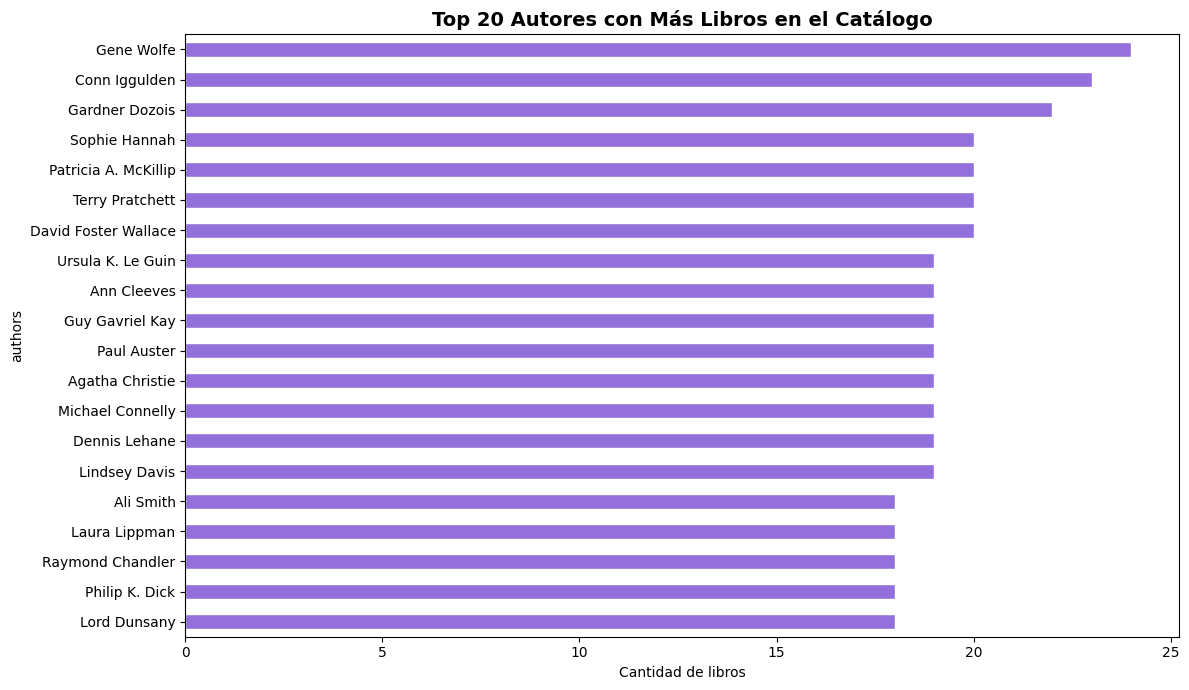


--- ANÁLISIS DE AÑO DE PUBLICACIÓN ---

   Nulos : 141
   Rango completo : 1820 — 2027
   Años fuera de rango (< 1800 o > 2025) : 125
   Libros con año válido : 10,685

   Libros por década:
     1820s      1  
     1830s      1  
     1870s      3  
     1880s      4  
     1890s     18  
     1900s     12  
     1910s      8  
     1920s     12  
     1930s      5  
     1940s      5  
     1950s     22  
     1960s     37  █
     1970s    102  ███
     1980s    284  █████████
     1990s   1021  ██████████████████████████████████
     2000s   2175  ████████████████████████████████████████████████████████████████████████
     2010s   4064  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
     2020s   2911  █████████████████████████████████████████████████████████████████████████████████████████████████


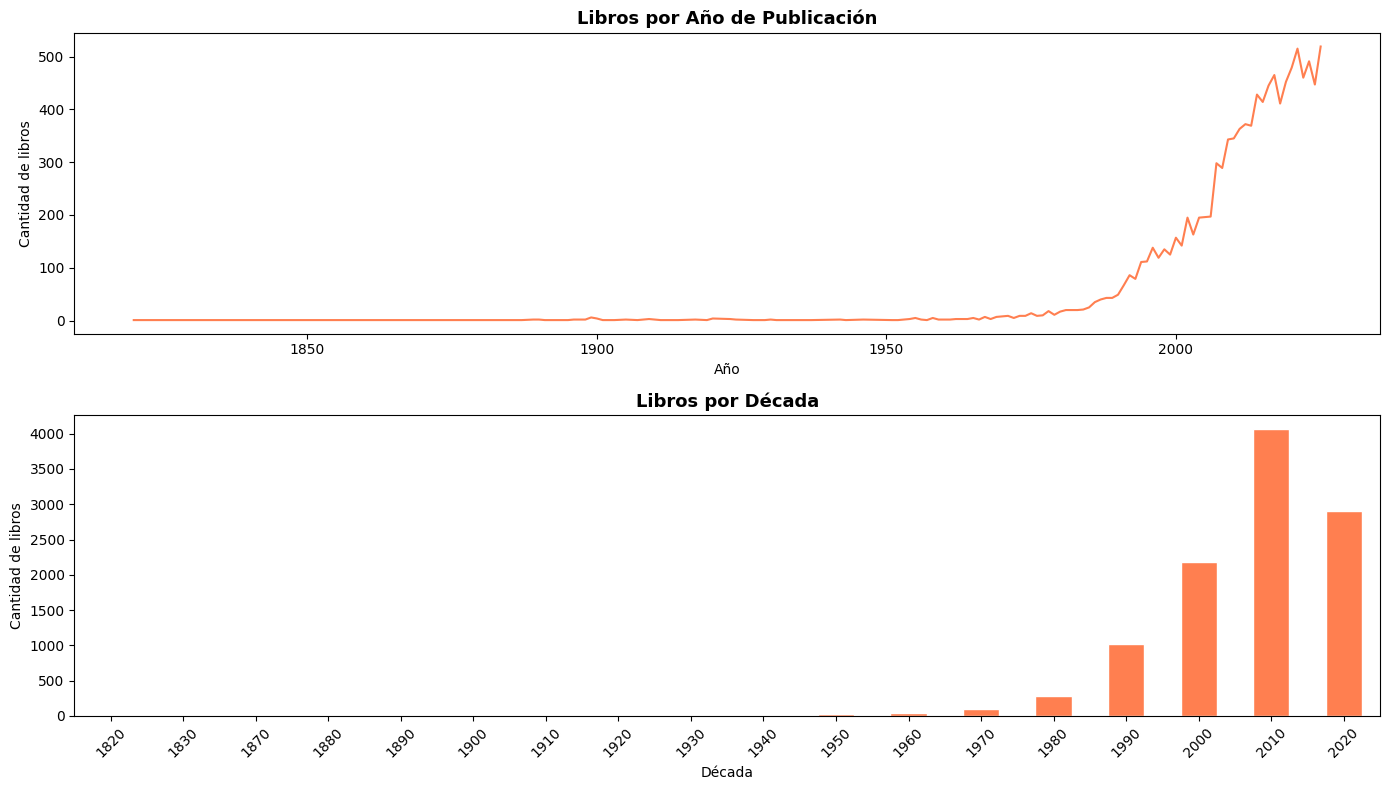


✅ Bloque 6 completado


In [ ]:
# ============================================================
# ANÁLISIS DE AUTORES
# Nos interesa saber cuántos autores únicos hay y si hay
# autores muy dominantes que puedan sesgar las recomendaciones
# ============================================================

print("--- ANÁLISIS DE AUTORES ---\n")

print(f"   Autores únicos : {df['authors'].nunique():,}")
print(f"   Nulos          : {df['authors'].isna().sum()}")

# Distribución: cuántos libros tiene cada autor
libros_por_autor = df['authors'].value_counts()

print(f"\n   Autores con 1 solo libro  : {(libros_por_autor == 1).sum():,}")
print(f"   Autores con 2-5 libros    : {((libros_por_autor >= 2) & (libros_por_autor <= 5)).sum():,}")
print(f"   Autores con más de 5      : {(libros_por_autor > 5).sum():,}")
print(f"   Autores con más de 10     : {(libros_por_autor > 10).sum():,}")

print(f"\n   Top 20 autores con más libros:")
print(libros_por_autor.head(20).to_string())

# Gráfico top 20 autores
fig, ax = plt.subplots(figsize=(12, 7))
libros_por_autor.head(20).sort_values().plot(
    kind='barh', ax=ax, color='mediumpurple', edgecolor='white'
)
ax.set_title("Top 20 Autores con Más Libros en el Catálogo", fontsize=14, fontweight='bold')
ax.set_xlabel("Cantidad de libros")
plt.tight_layout()
plt.show()

# ============================================================
# ANÁLISIS DE AÑO DE PUBLICACIÓN
# Nos dice qué tan contemporáneo es el catálogo.
# También detectamos valores raros (años imposibles).
# ============================================================

print("\n--- ANÁLISIS DE AÑO DE PUBLICACIÓN ---\n")

print(f"   Nulos : {df['year'].isna().sum():,}")
print(f"   Rango completo : {df['year'].min():.0f} — {df['year'].max():.0f}")

# Detectar años fuera de rango lógico
fuera_rango = df[(df['year'] < 1800) | (df['year'] > 2025)].shape[0]
print(f"   Años fuera de rango (< 1800 o > 2025) : {fuera_rango}")

# Filtrar rango válido para el análisis
df_year = df[(df['year'] >= 1800) & (df['year'] <= 2025)]
print(f"   Libros con año válido : {len(df_year):,}")

# Décadas: agrupamos por década para ver tendencias más claras
df_year = df_year.copy()
df_year['decada'] = (df_year['year'] // 10 * 10).astype(int)
decadas = df_year['decada'].value_counts().sort_index()

print(f"\n   Libros por década:")
for dec, count in decadas.items():
    barra = '█' * (count // 30)   # Barra visual simple en consola
    print(f"     {dec}s  {count:>5}  {barra}")

# Gráfico por año
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Arriba: evolución por año
df_year['year'].value_counts().sort_index().plot(
    ax=axes[0], color='coral', linewidth=1.5
)
axes[0].set_title("Libros por Año de Publicación", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Cantidad de libros")

# Abajo: por década (más legible para tendencias largas)
decadas.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title("Libros por Década", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Década")
axes[1].set_ylabel("Cantidad de libros")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✅ Bloque 6 completado")

--- ANÁLISIS DE PAGE_COUNT ---

   Nulos              : 68
   Con 0 páginas      : 626
   Promedio           : 411 páginas
   Mediana            : 284 páginas
   Mínimo (sin ceros) : 1 páginas
   Máximo             : 23126 páginas

   Libros con más de 2,000 páginas (posibles errores):
                                                                                                                                                                        title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

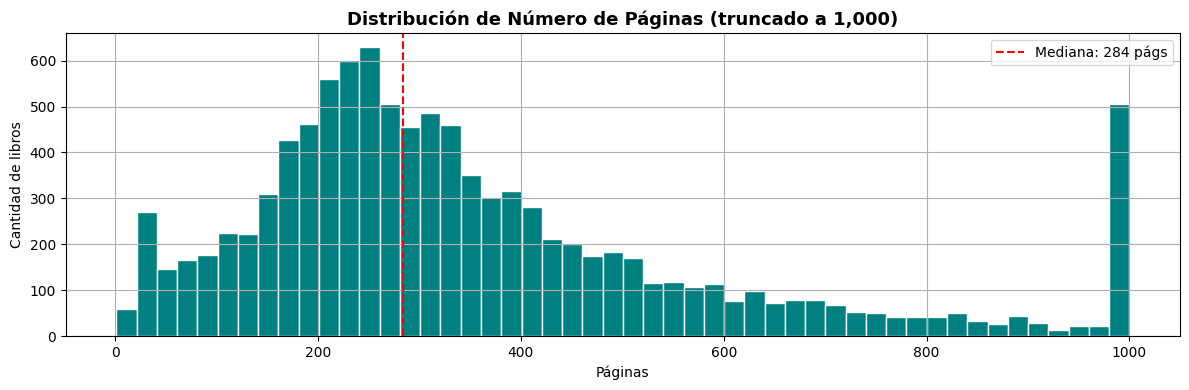


--- RESUMEN ESTADÍSTICO GENERAL ---

       page_count     year  desc_len
count     10883.0  10810.0   10951.0
mean        411.3   2011.1     991.1
std         872.3     14.0     770.3
min           0.0   1820.0       1.0
25%         185.0   2006.0     393.0
50%         284.0   2014.0     892.0
75%         433.0   2020.0    1363.5
max       23126.0   2027.0   14015.0

✅ Bloque 7 completado


In [ ]:
# ============================================================
# ANÁLISIS DE PAGE_COUNT
# No es crítico para el pipeline NLP, pero nos ayuda a
# detectar registros claramente erróneos (ej: 0 páginas)
# ============================================================

print("--- ANÁLISIS DE PAGE_COUNT ---\n")

print(f"   Nulos              : {df['page_count'].isna().sum():,}")
print(f"   Con 0 páginas      : {(df['page_count'] == 0).sum():,}")
print(f"   Promedio           : {df['page_count'].mean():.0f} páginas")
print(f"   Mediana            : {df['page_count'].median():.0f} páginas")
print(f"   Mínimo (sin ceros) : {df[df['page_count'] > 0]['page_count'].min():.0f} páginas")
print(f"   Máximo             : {df['page_count'].max():.0f} páginas")

# Libros con page_count sospechosamente alto (posibles errores)
print(f"\n   Libros con más de 2,000 páginas (posibles errores):")
print(df[df['page_count'] > 2000][['title', 'authors', 'page_count']].to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(12, 4))
df[df['page_count'] > 0]['page_count'].clip(upper=1000).hist(
    bins=50, ax=ax, color='teal', edgecolor='white'
)
ax.set_title("Distribución de Número de Páginas (truncado a 1,000)", fontsize=13, fontweight='bold')
ax.set_xlabel("Páginas")
ax.set_ylabel("Cantidad de libros")
ax.axvline(x=df['page_count'].median(), color='red', linestyle='--',
           label=f"Mediana: {df['page_count'].median():.0f} págs")
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# RESUMEN ESTADÍSTICO GENERAL
# df.describe() da un resumen de todas las columnas numéricas:
# count, mean, std (desviación estándar), min, percentiles, max
# ============================================================
print("\n--- RESUMEN ESTADÍSTICO GENERAL ---\n")
print(df[['page_count', 'year', 'desc_len']].describe().round(1).to_string())

print("\n✅ Bloque 7 completado")

In [ ]:
# ============================================================
# DEDUPLICACIÓN FUZZY
# ============================================================
# El problema: el mismo libro puede aparecer así:
#   "White Nights" — Fyodor Dostoevsky
#   "White Nights and Other Stories" — Fyodor Dostoyevsky
#   "White Nights and Other Stories: Volume X" — F. Dostoevsky
#
# Una deduplicación exacta no los detecta como iguales.
# Necesitamos comparar por SIMILITUD, no por igualdad.
#
# Estrategia:
# 1. Ordenar por longitud de descripción (desc) → nos quedamos
#    con la versión más completa de cada libro
# 2. Recorrer cada libro y compararlo con los ya aceptados
# 3. Si título Y autor son suficientemente similares → duplicado
# ============================================================

from rapidfuzz import fuzz
import re

# ============================================================
# FUNCIONES DE NORMALIZACIÓN Y COMPARACIÓN
# ============================================================

def normalizar(texto):
    """
    Limpia un string para comparación:
    'Fyodor M. Dostoevsky' → 'fyodor m dostoevsky'
    Elimina puntuación, minúsculas, espacios extra.
    """
    if pd.isna(texto) or texto == "":
        return ""
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', '', texto)   # Elimina puntuación
    texto = re.sub(r'\s+', ' ', texto).strip()  # Espacios extra
    return texto

def apellido(autor):
    """
    Extrae el apellido del autor (última palabra del nombre).
    'Fyodor M Dostoevsky' → 'dostoevsky'
    Es la parte más estable del nombre para comparar.
    """
    norm = normalizar(autor)
    if not norm:
        return ""
    partes = norm.split()
    return partes[-1] if partes else ""

def mismo_autor(autor1, autor2, umbral=85):
    """
    Retorna True si los dos autores parecen ser la misma persona.
    Compara apellidos con similitud fuzzy.
    umbral=85: necesitamos 85% de similitud mínima.
    Ejemplo: 'dostoevsky' vs 'dostoyevsky' → ~91% → True
    """
    ap1 = apellido(autor1)
    ap2 = apellido(autor2)
    if not ap1 or not ap2:
        return False
    # Comparación por apellido
    if fuzz.ratio(ap1, ap2) >= umbral:
        return True
    # Comparación por nombre completo normalizado (red de seguridad)
    if fuzz.ratio(normalizar(autor1), normalizar(autor2)) >= umbral:
        return True
    return False

def mismo_titulo(titulo1, titulo2, umbral=88):
    """
    Retorna True si los dos títulos parecen ser el mismo libro.
    Maneja dos casos:
    A) Títulos muy similares: fuzz.ratio alto
    B) Uno es subtítulo del otro:
       'white nights' está contenido en
       'white nights and other stories volume x'
    """
    t1 = normalizar(titulo1)
    t2 = normalizar(titulo2)
    if not t1 or not t2:
        return False

    # Caso A: similitud directa
    if fuzz.ratio(t1, t2) >= umbral:
        return True

    # Caso B: el título más corto está al inicio del más largo
    corto = t1 if len(t1) <= len(t2) else t2
    largo = t2 if len(t1) <= len(t2) else t1

    # Mínimo 8 chars para evitar falsos positivos
    # (ej: "It" no debe matchear con "It Ends With Us")
    if len(corto) >= 8 and largo.startswith(corto):
        return True

    return False

# ============================================================
# PREPARACIÓN: filtrar descripciones útiles y ordenar
# ============================================================

# Paso 1: quedarnos solo con libros con descripción >= 100 chars
desc_ok = df['desc_len'] >= 100
df_filtrado = df[desc_ok].copy()
print(f"Libros con descripción útil (>= 100 chars): {len(df_filtrado):,}")
print(f"Descartados por descripción corta          : {(~desc_ok).sum():,}")

# Paso 2: ordenar por longitud de descripción descendente
# Así cuando encontremos duplicados, conservamos el más completo
df_sorted = df_filtrado.sort_values('desc_len', ascending=False).reset_index(drop=True)

print(f"\nIniciando deduplicación fuzzy...")
print(f"Esto puede tardar 3-6 minutos con {len(df_sorted):,} libros. Es normal ☕")

# ============================================================
# ALGORITMO DE DEDUPLICACIÓN
# ============================================================

indices_unicos = []   # Índices de libros aceptados como únicos
aceptados = []        # Lista de (titulo_norm, apellido_norm) ya aceptados

for i, row in df_sorted.iterrows():
    titulo_i   = normalizar(row['title'])
    apellido_i = apellido(row['authors'])

    es_duplicado = False

    for titulo_a, apellido_a in aceptados:

        # Primero verificamos autor (descarte rápido si son distintos)
        if not mismo_autor(apellido_i, apellido_a):
            continue  # Autores distintos → imposible ser duplicado

        # Si el autor coincide, verificamos el título
        if mismo_titulo(titulo_i, titulo_a):
            es_duplicado = True
            break  # Duplicado encontrado, no seguimos buscando

    if not es_duplicado:
        indices_unicos.append(i)
        aceptados.append((titulo_i, apellido_i))

    # Progreso cada 1000 libros
    if (i + 1) % 1000 == 0:
        print(f"  Procesados: {i + 1:,} / {len(df_sorted):,}")

print(f"\n✅ Deduplicación completada")

# ============================================================
# CONSTRUIR DATASET FINAL
# ============================================================
df_clean = df_sorted.loc[indices_unicos].reset_index(drop=True)
df_clean = df_clean.drop(columns=['desc_len', 'categories_list'], errors='ignore')

# ============================================================
# REPORTE
# ============================================================
print("\n" + "=" * 55)
print("RESULTADO FINAL DE DEDUPLICACIÓN")
print("=" * 55)
print(f"""
  Libros originales              : {len(df):,}
  Después de filtrar desc cortas : {len(df_filtrado):,}
  Después de deduplicación fuzzy : {len(df_clean):,}
  ─────────────────────────────────────────
  Total eliminados               : {len(df) - len(df_clean):,}
""")

# Muestra ejemplos de duplicados eliminados para verificar
print("Ejemplos de duplicados detectados y eliminados:")
eliminados = df_sorted[~df_sorted.index.isin(indices_unicos)][['title', 'authors']].head(15)
print(eliminados.to_string(index=False))

print("\n✅ Bloque 8 completado")

Libros con descripción útil (>= 100 chars): 10,500
Descartados por descripción corta          : 451

Iniciando deduplicación fuzzy...
Esto puede tardar 3-6 minutos con 10,500 libros. Es normal ☕
  Procesados: 1,000 / 10,500
  Procesados: 2,000 / 10,500
  Procesados: 3,000 / 10,500
  Procesados: 4,000 / 10,500
  Procesados: 5,000 / 10,500
  Procesados: 6,000 / 10,500
  Procesados: 7,000 / 10,500
  Procesados: 8,000 / 10,500
  Procesados: 9,000 / 10,500
  Procesados: 10,000 / 10,500

✅ Deduplicación completada

RESULTADO FINAL DE DEDUPLICACIÓN

  Libros originales              : 10,951
  Después de filtrar desc cortas : 10,500
  Después de deduplicación fuzzy : 9,409
  ─────────────────────────────────────────
  Total eliminados               : 1,542

Ejemplos de duplicados detectados y eliminados:
                                                             title                                             authors
                         Cozy Cat Caper Mystery Box Set: Books 7-9       

In [ ]:
# ============================================================
# DEDUPLICACIÓN FUZZY — VERSIÓN 2 (umbrales más estrictos)
# ============================================================
# Problema detectado en v1:
# - "Books 7-9" y "Books 10-12" se marcaban como duplicados
#   porque el título base era muy similar
# - Ediciones anotadas/ilustradas se perdían innecesariamente
#
# Solución:
# 1. Subir umbral de título de 88 → 92
# 2. Detectar y respetar indicadores de volumen/número
#    (Books 1-3, Volume X, Part 2, etc.)
# 3. Ser más cuidadosos con el caso "subtítulo contenido"
# ============================================================

from rapidfuzz import fuzz
import re

# ============================================================
# INDICADORES QUE DIFERENCIAN EDICIONES O VOLÚMENES
# Si un título contiene estos patrones, NO es duplicado
# aunque el resto del título sea idéntico
# ============================================================
PATRONES_VOLUMEN = [
    r'\bbooks?\s*\d',        # "book 2", "books 7-9"
    r'\bvol(ume)?\s*\.?\s*\d',  # "volume 2", "vol. 3"
    r'\bpart\s*\d',          # "part 2"
    r'\b(box\s*set)',        # "box set"
    r'#\s*\d',               # "#2", "# 3"
    r'\bdeluxe\s*\d',        # "deluxe 5"
    r'\b(omnibus)',          # "omnibus"
    r'\d+\s*-\s*\d+',        # "7-9", "1-3" (rangos de números)
]

def tiene_numero_volumen(titulo):
    """
    Retorna True si el título contiene indicadores de volumen/número.
    'Cozy Cat Books 7-9' → True
    'White Nights' → False
    """
    titulo_lower = titulo.lower()
    for patron in PATRONES_VOLUMEN:
        if re.search(patron, titulo_lower):
            return True
    return False

def normalizar(texto):
    """Limpia texto para comparación: minúsculas, sin puntuación, sin espacios extra."""
    if pd.isna(texto) or texto == "":
        return ""
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

def apellido(autor):
    """Extrae apellido (última palabra) del nombre del autor."""
    norm = normalizar(autor)
    if not norm:
        return ""
    partes = norm.split()
    return partes[-1] if partes else ""

def mismo_autor(autor1, autor2, umbral=85):
    """True si los autores parecen ser la misma persona."""
    ap1 = apellido(autor1)
    ap2 = apellido(autor2)
    if not ap1 or not ap2:
        return False
    if fuzz.ratio(ap1, ap2) >= umbral:
        return True
    if fuzz.ratio(normalizar(autor1), normalizar(autor2)) >= umbral:
        return True
    return False

def mismo_titulo(titulo1, titulo2, umbral=92):
    """
    True si los títulos parecen ser el mismo libro.
    Versión mejorada:
    - Umbral subido de 88 → 92 (más estricto)
    - Si cualquiera de los dos tiene número de volumen → NO es duplicado
    - El caso 'subtítulo contenido' requiere que el título corto
      sea significativo (>= 12 chars, no solo 8)
    """
    t1 = normalizar(titulo1)
    t2 = normalizar(titulo2)
    if not t1 or not t2:
        return False

    # NUEVA REGLA: si alguno tiene número de volumen/serie
    # son libros distintos aunque el título base sea igual
    if tiene_numero_volumen(titulo1) or tiene_numero_volumen(titulo2):
        # Solo los marcamos como duplicados si son EXACTAMENTE iguales
        return fuzz.ratio(t1, t2) >= 98

    # Caso A: similitud directa alta (umbral más estricto: 92)
    if fuzz.ratio(t1, t2) >= umbral:
        return True

    # Caso B: subtítulo contenido en título más largo
    # Ahora exigimos mínimo 12 chars (antes era 8) para evitar
    # falsos positivos con títulos cortos comunes
    corto = t1 if len(t1) <= len(t2) else t2
    largo = t2 if len(t1) <= len(t2) else t1

    if len(corto) >= 12 and largo.startswith(corto):
        # Verificación extra: lo que viene después del título corto
        # no debe ser un número (indicaría volumen distinto)
        resto = largo[len(corto):].strip()
        if not re.match(r'^\d', resto):  # No empieza con número
            return True

    return False

# ============================================================
# EJECUTAR DEDUPLICACIÓN CON UMBRALES CORREGIDOS
# ============================================================

# Reusamos df_sorted del bloque anterior (ya filtrado y ordenado)
print(f"Libros a procesar: {len(df_sorted):,}")
print("Iniciando deduplicación v2... ☕")

indices_unicos_v2 = []
aceptados_v2 = []   # (titulo_norm, apellido_norm, titulo_original)

for i, row in df_sorted.iterrows():
    titulo_i   = normalizar(row['title'])
    apellido_i = apellido(row['authors'])

    es_duplicado = False

    for titulo_a, apellido_a in aceptados_v2:
        if not mismo_autor(apellido_i, apellido_a):
            continue
        if mismo_titulo(titulo_i, titulo_a):
            es_duplicado = True
            break

    if not es_duplicado:
        indices_unicos_v2.append(i)
        aceptados_v2.append((titulo_i, apellido_i))

    if (i + 1) % 1000 == 0:
        print(f"  Procesados: {i + 1:,} / {len(df_sorted):,}")

print(f"\n✅ Deduplicación v2 completada")

# ============================================================
# COMPARAR v1 vs v2
# ============================================================
df_clean_v2 = df_sorted.loc[indices_unicos_v2].reset_index(drop=True)
df_clean_v2 = df_clean_v2.drop(columns=['desc_len', 'categories_list'], errors='ignore')

print("\n" + "=" * 50)
print("COMPARACIÓN v1 vs v2")
print("=" * 50)
print(f"  Deduplicación v1 (umbral 88) : {len(df_sorted) - len(indices_unicos):,}  eliminados → {len(indices_unicos):,} libros")
print(f"  Deduplicación v2 (umbral 92) : {len(df_sorted) - len(indices_unicos_v2):,}  eliminados → {len(indices_unicos_v2):,} libros")

# ============================================================
# VERIFICACIÓN: revisar sample de eliminados en v2
# ============================================================
df_eliminados_v2 = df_sorted[~df_sorted.index.isin(indices_unicos_v2)][
    ['title', 'authors']
]

print(f"\nMuestra de eliminados en v2 (verificar que sean realmente duplicados):")
print(df_eliminados_v2.head(20).to_string(index=False))

# ============================================================
# VERIFICAR QUE LOS BOX SETS YA NO SE ELIMINAN
# ============================================================
print("\n¿Los Box Sets fueron conservados?")
box_sets = df_clean_v2[df_clean_v2['title'].str.contains('Box Set|box set', na=False)]
print(f"  Box Sets en dataset final: {len(box_sets)}")
print(box_sets[['title', 'authors']].head(10).to_string(index=False))

print("\n✅ Bloque 9 completado")

Libros a procesar: 10,500
Iniciando deduplicación v2... ☕
  Procesados: 1,000 / 10,500
  Procesados: 2,000 / 10,500
  Procesados: 3,000 / 10,500
  Procesados: 4,000 / 10,500
  Procesados: 5,000 / 10,500
  Procesados: 6,000 / 10,500
  Procesados: 7,000 / 10,500
  Procesados: 8,000 / 10,500
  Procesados: 9,000 / 10,500
  Procesados: 10,000 / 10,500

✅ Deduplicación v2 completada

COMPARACIÓN v1 vs v2
  Deduplicación v1 (umbral 88) : 1,091  eliminados → 9,409 libros
  Deduplicación v2 (umbral 92) : 968  eliminados → 9,532 libros

Muestra de eliminados en v2 (verificar que sean realmente duplicados):
                                                                                                                                                                                                  title                                                                                                                                                                                                     

In [ ]:
# ============================================================
# DEDUPLICACIÓN FUZZY — VERSIÓN FINAL
# Regla simple: un libro por autor.
# Si dos títulos son del mismo autor y parecen el mismo libro
# (incluyendo ediciones anotadas, ilustradas, resumidas, etc.)
# nos quedamos con el que tiene la descripción más larga.
# ============================================================

from rapidfuzz import fuzz
import re

PATRONES_VOLUMEN = [
    r'\bbooks?\s*\d',
    r'\bvol(ume)?\s*\.?\s*\d',
    r'\bpart\s*\d',
    r'\b(box\s*set)',
    r'#\s*\d',
    r'\bdeluxe\s*\d',
    r'\b(omnibus)',
    r'\d+\s*-\s*\d+',
]

def tiene_numero_volumen(titulo):
    titulo_lower = titulo.lower()
    for patron in PATRONES_VOLUMEN:
        if re.search(patron, titulo_lower):
            return True
    return False

def normalizar(texto):
    if pd.isna(texto) or texto == "":
        return ""
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

def apellido(autor):
    norm = normalizar(autor)
    if not norm:
        return ""
    partes = norm.split()
    return partes[-1] if partes else ""

def mismo_autor(autor1, autor2, umbral=85):
    ap1 = apellido(autor1)
    ap2 = apellido(autor2)
    if not ap1 or not ap2:
        return False
    if fuzz.ratio(ap1, ap2) >= umbral:
        return True
    if fuzz.ratio(normalizar(autor1), normalizar(autor2)) >= umbral:
        return True
    return False

def mismo_titulo(titulo1, titulo2, umbral=92):
    """
    Regla final:
    - Si alguno tiene número de volumen → solo duplicado si son 98% iguales
    - Resto → umbral 92 o subtítulo contenido
    """
    t1 = normalizar(titulo1)
    t2 = normalizar(titulo2)
    if not t1 or not t2:
        return False

    # Volúmenes y series: solo duplicado si son prácticamente idénticos
    if tiene_numero_volumen(titulo1) or tiene_numero_volumen(titulo2):
        return fuzz.ratio(t1, t2) >= 98

    # Similitud directa
    if fuzz.ratio(t1, t2) >= umbral:
        return True

    # Subtítulo contenido en título más largo
    corto = t1 if len(t1) <= len(t2) else t2
    largo = t2 if len(t1) <= len(t2) else t1
    if len(corto) >= 12 and largo.startswith(corto):
        resto = largo[len(corto):].strip()
        if not re.match(r'^\d', resto):
            return True

    return False

# ============================================================
# EJECUTAR
# ============================================================
print(f"Libros a procesar: {len(df_sorted):,}")
print("Iniciando deduplicación final... ☕")

indices_finales = []
aceptados_final = []

for i, row in df_sorted.iterrows():
    titulo_i   = normalizar(row['title'])
    apellido_i = apellido(row['authors'])
    es_duplicado = False

    for titulo_a, apellido_a in aceptados_final:
        if not mismo_autor(apellido_i, apellido_a):
            continue
        if mismo_titulo(titulo_i, titulo_a):
            es_duplicado = True
            break

    if not es_duplicado:
        indices_finales.append(i)
        aceptados_final.append((titulo_i, apellido_i))

    if (i + 1) % 1000 == 0:
        print(f"  Procesados: {i + 1:,} / {len(df_sorted):,}")

print(f"\n✅ Deduplicación completada")

# ============================================================
# DATASET FINAL
# ============================================================
df_clean = df_sorted.loc[indices_finales].reset_index(drop=True)
df_clean = df_clean.drop(columns=['desc_len', 'categories_list'], errors='ignore')

print("\n" + "=" * 55)
print("RESULTADO FINAL")
print("=" * 55)
print(f"""
  Libros originales              : {len(df):,}
  Descartados (desc < 100 chars) : {len(df) - len(df_filtrado):,}
  Descartados (duplicados fuzzy) : {len(df_filtrado) - len(df_clean):,}
  ─────────────────────────────────────────
  DATASET FINAL                  : {len(df_clean):,} libros
  Categorías únicas              : {df_clean['assigned_category'].nunique()}
  Autores únicos                 : {df_clean['authors'].nunique():,}
""")

# ============================================================
# GUARDAR EN DRIVE
# ============================================================
SAVE_PATH = "/content/drive/MyDrive/books_clean.csv"
df_clean.to_csv(SAVE_PATH, index=False)

print(f"✅ Guardado: {SAVE_PATH}")
print("\n🎉 FASE 1 COMPLETADA — Listos para Fase 2")

Libros a procesar: 10,500
Iniciando deduplicación final... ☕
  Procesados: 1,000 / 10,500
  Procesados: 2,000 / 10,500
  Procesados: 3,000 / 10,500
  Procesados: 4,000 / 10,500
  Procesados: 5,000 / 10,500
  Procesados: 6,000 / 10,500
  Procesados: 7,000 / 10,500
  Procesados: 8,000 / 10,500
  Procesados: 9,000 / 10,500
  Procesados: 10,000 / 10,500

✅ Deduplicación completada

RESULTADO FINAL

  Libros originales              : 10,951
  Descartados (desc < 100 chars) : 451
  Descartados (duplicados fuzzy) : 968
  ─────────────────────────────────────────
  DATASET FINAL                  : 9,532 libros
  Categorías únicas              : 23
  Autores únicos                 : 6,680

✅ Guardado: /content/drive/MyDrive/books_clean.csv

🎉 FASE 1 COMPLETADA — Listos para Fase 2
